# Ejercicio PCA (Principal Component Analysis)
En este ejercicio vas a trabajar con un dataset de información de ciudadanos como el estado civil, número de hijos, qué gastos e ingresos tiene, etc...

Se cuenta con un target, que es si el ciudadano va a alquilar o a comprar una vivienda. Para ello,  con PCA

### Importamos librerias
Principales librerías que usarás durante el notebook.

In [77]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

### Cargamos datos de entrada
1. Carga el csv *comprar_alquilar.csv*
2. Obtén la información básica: columnas, dimensiones, descripción de las variables, missings...

In [78]:
df = pd.read_csv("data/comprar_alquilar.csv")

In [79]:
df.shape

(202, 10)

In [80]:
df.shape

(202, 10)

In [81]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 202 entries, 0 to 201
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   ingresos        202 non-null    int64
 1   gastos_comunes  202 non-null    int64
 2   pago_coche      202 non-null    int64
 3   gastos_otros    202 non-null    int64
 4   ahorros         202 non-null    int64
 5   vivienda        202 non-null    int64
 6   estado_civil    202 non-null    int64
 7   hijos           202 non-null    int64
 8   trabajo         202 non-null    int64
 9   comprar         202 non-null    int64
dtypes: int64(10)
memory usage: 15.9 KB


In [82]:
df.head()

,ingresos,gastos_comunes,pago_coche,gastos_otros,ahorros,vivienda,estado_civil,hijos,trabajo,comprar
0,6000,1000,0,600,50000,400000,0,2,2,1
1,6745,944,123,429,43240,636897,1,3,6,0
2,6455,1033,98,795,57463,321779,2,1,8,1
3,7098,1278,15,254,54506,660933,0,0,3,0
4,6167,863,223,520,41512,348932,0,0,3,1


In [83]:
df.describe()

,ingresos,gastos_comunes,pago_coche,gastos_otros,ahorros,vivienda,estado_civil,hijos,trabajo,comprar
count,202.000000,202.000000,202.000000,202.000000,202.000000,202.000000,202.000000,202.000000,202.000000,202.000000
mean,4958.995050,971.584158,211.742574,515.425743,38749.668317,373349.638614,1.024752,1.232673,4.490099,0.331683
std,1682.862556,272.106351,124.940754,168.103075,17365.231870,136371.525622,0.837184,1.367833,2.535794,0.471988
min,2008.000000,384.000000,0.000000,201.000000,10319.000000,176553.000000,0.000000,0.000000,0.000000,0.000000
25%,3513.750000,766.750000,99.000000,383.250000,24964.250000,274810.000000,0.000000,0.000000,2.000000,0.000000
50%,4947.500000,968.000000,208.500000,522.500000,38523.000000,340783.500000,1.000000,1.000000,5.000000,0.000000
75%,6374.500000,1165.250000,318.750000,656.750000,52150.750000,444482.000000,2.000000,2.000000,7.000000,1.000000
max,7984.000000,1585.000000,448.000000,828.000000,69934.000000,669540.000000,2.000000,4.000000,8.000000,1.000000


### Visualicemos las dimensiones
Realiza un análisis univariante. Realiza la gráfica que consideres para cada variable, diferenciando por colores el target (*comprar*).

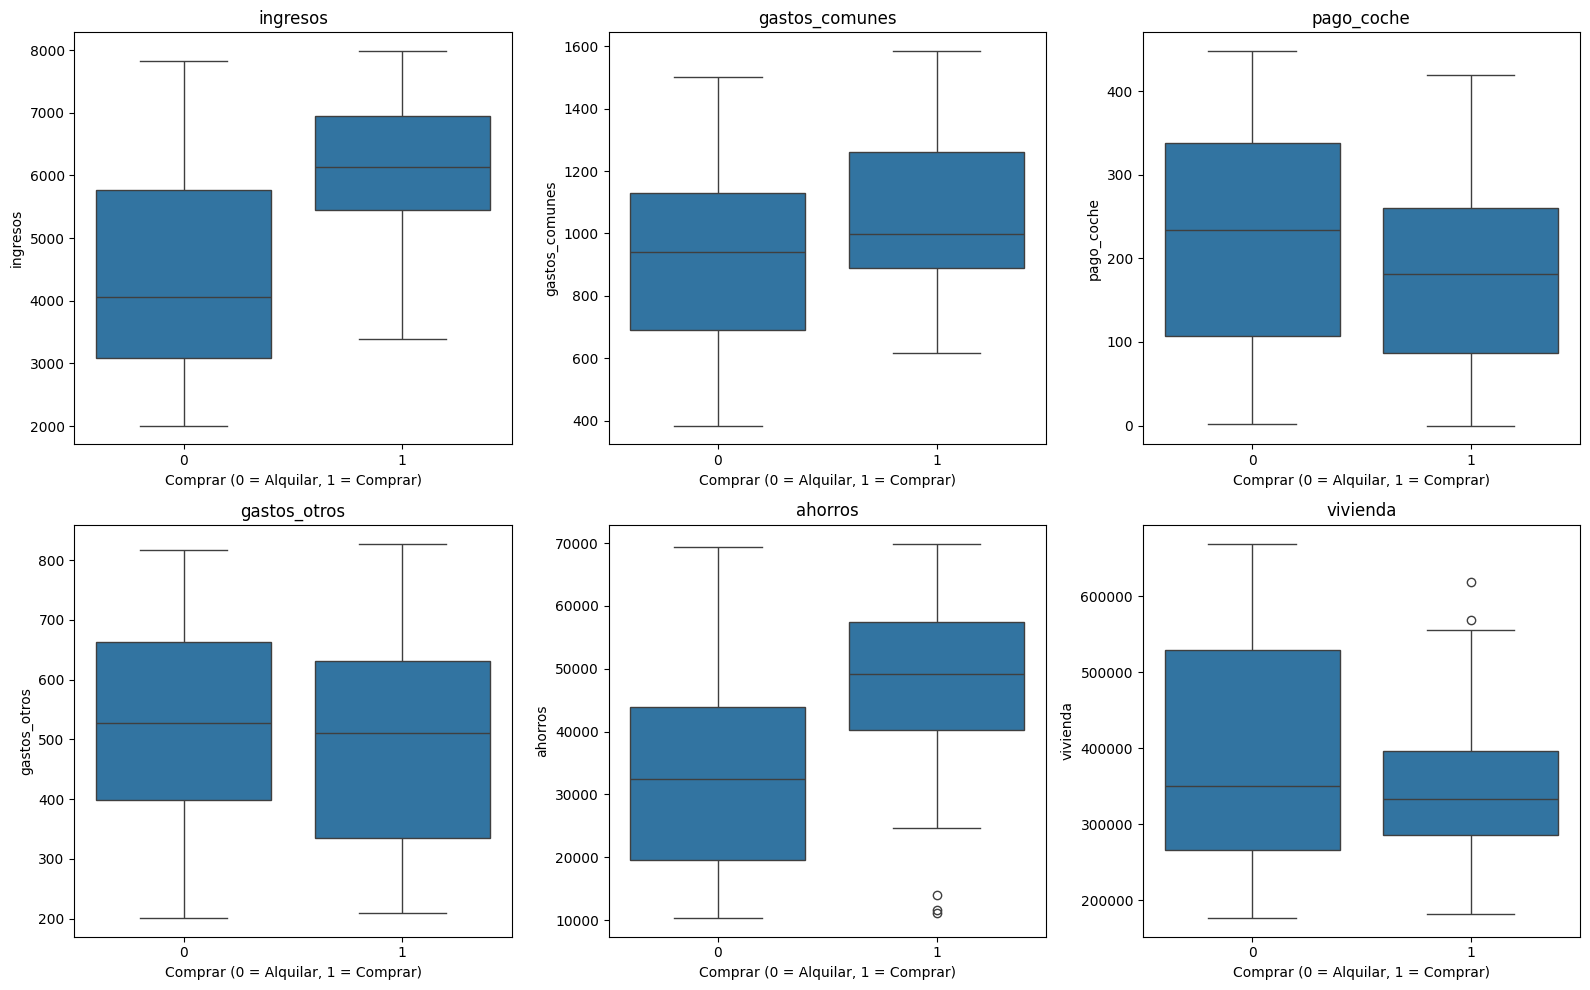

In [84]:
features = [
    "ingresos",
    "gastos_comunes",
    "pago_coche",
    "gastos_otros",
    "ahorros",
    "vivienda"
]

plt.figure(figsize=(16, 10))

for i, col in enumerate(features, 1):
    plt.subplot(2, 3, i)
    sns.boxplot(
        data=df,
        x="comprar",
        y=col
    )
    plt.title(col)
    plt.xlabel("Comprar (0 = Alquilar, 1 = Comprar)")

plt.tight_layout()
plt.show()

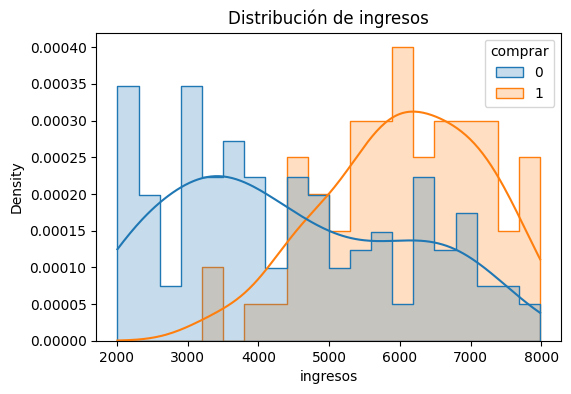

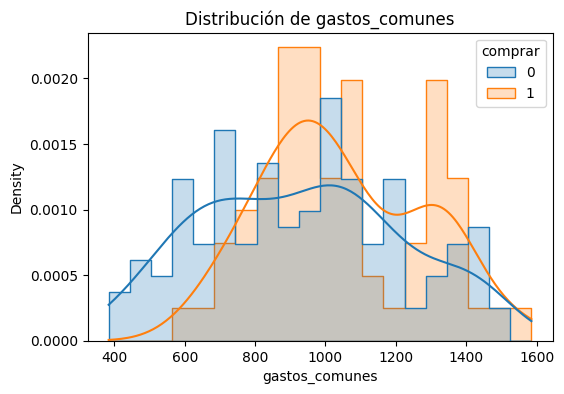

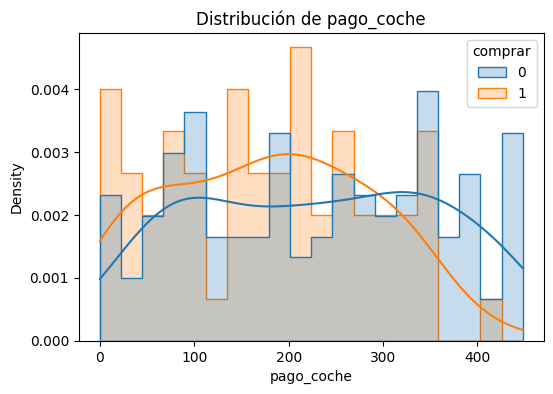

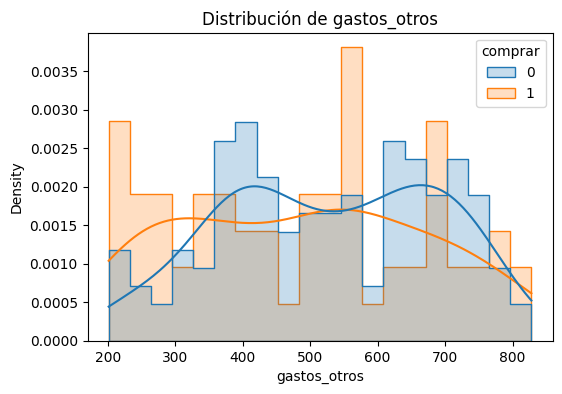

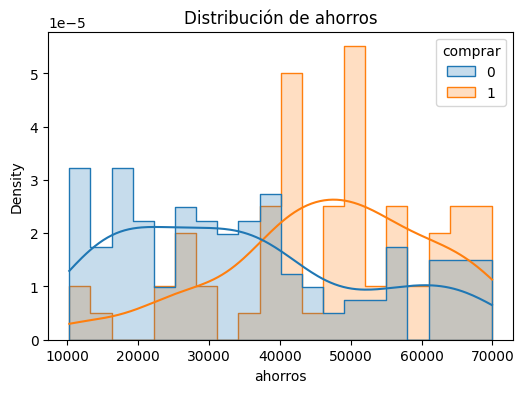

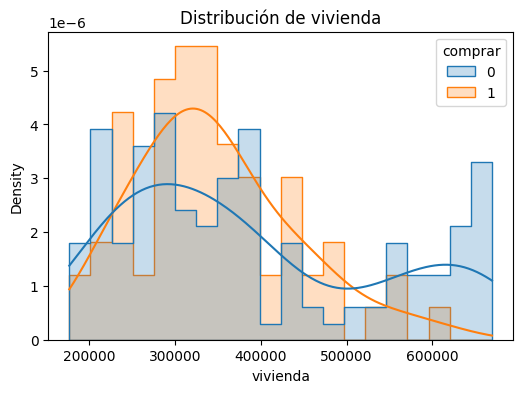

In [85]:
features = [
    "ingresos",
    "gastos_comunes",
    "pago_coche",
    "gastos_otros",
    "ahorros",
    "vivienda"
]

for col in features:
    plt.figure(figsize=(6, 4))
    sns.histplot(
        data=df,
        x=col,
        hue="comprar",
        bins=20,
        kde=True,
        element="step",
        stat="density",
        common_norm=False
    )
    plt.title(f"Distribución de {col}")
    plt.show()


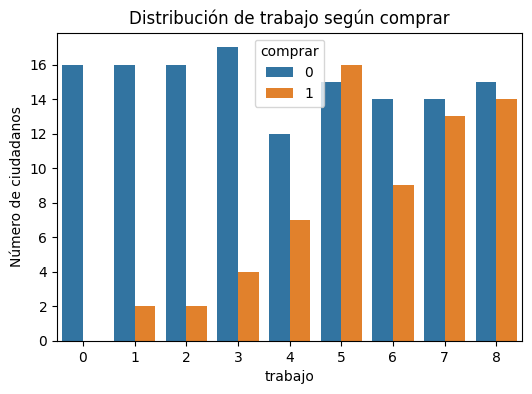

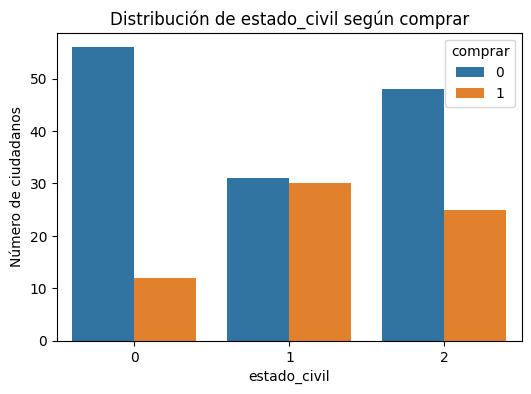

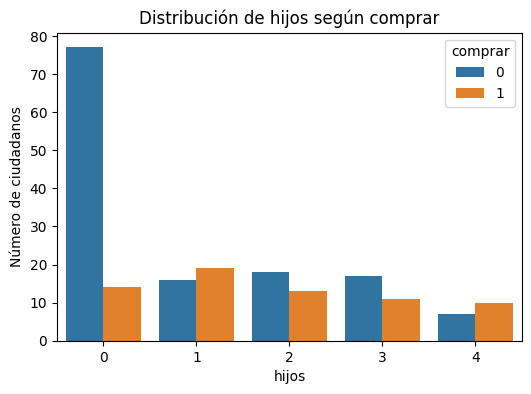

In [86]:
cat_features = ["trabajo", "estado_civil", "hijos"]

for col in cat_features:
    plt.figure(figsize=(6, 4))
    sns.countplot(
        data=df,
        x=col,
        hue="comprar"
    )
    plt.title(f"Distribución de {col} según comprar")
    plt.xlabel(col)
    plt.ylabel("Número de ciudadanos")
    plt.show()


## Estandariza los datos
Como el objetivo de estos primeros apartados no es encontrar el mejor modelo con el mejor accuracy, por sencillez, no es necesario dividir en train y test.

In [87]:
features_pca = [
    "ingresos",
    "gastos_comunes",
    "pago_coche",
    "gastos_otros",
    "ahorros",
    "vivienda",
    "estado_civil",
    "hijos",
    "trabajo"
]

X = df[features_pca]

In [88]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [89]:
X_scaled = pd.DataFrame(
    X_scaled,
    columns=features_pca
)

In [90]:
X_scaled.describe()

,ingresos,gastos_comunes,pago_coche,gastos_otros,ahorros,vivienda,estado_civil,hijos,trabajo
count,2.020000e+02,2.020000e+02,2.020000e+02,2.020000e+02,2.020000e+02,2.020000e+02,2.020000e+02,2.020000e+02,2.020000e+02
mean,-1.319077e-16,9.013692e-17,1.143200e-16,-2.462277e-16,8.903769e-17,-1.121215e-16,-2.198461e-18,1.758769e-17,3.627461e-17
std,1.002484e+00,1.002484e+00,1.002484e+00,1.002484e+00,1.002484e+00,1.002484e+00,1.002484e+00,1.002484e+00,1.002484e+00
min,-1.757913e+00,-2.164757e+00,-1.698954e+00,-1.875081e+00,-1.641286e+00,-1.446677e+00,-1.227088e+00,-9.034260e-01,-1.775087e+00
25%,-8.609353e-01,-7.546427e-01,-9.046102e-01,-7.882314e-01,-7.958240e-01,-7.243774e-01,-1.227088e+00,-9.034260e-01,-9.844198e-01
50%,-6.847623e-03,-1.320463e-02,-2.601737e-02,4.218741e-02,-1.308543e-02,-2.393978e-01,-2.963981e-02,-1.705262e-01,2.015810e-01
75%,8.432190e-01,7.134968e-01,8.585932e-01,8.427887e-01,7.736365e-01,5.229031e-01,1.167809e+00,5.623736e-01,9.922482e-01
max,1.802001e+00,2.259925e+00,1.895654e+00,1.864040e+00,1.800253e+00,2.177333e+00,1.167809e+00,2.028173e+00,1.387582e+00


## Aplicamos PCA
Aplica el algoritmo de PCA para 9 components, es decir, para todas las features

In [91]:
pca = PCA(n_components=9)
X_pca = pca.fit_transform(X_scaled)

In [92]:
pc_columns = [f"PC{i+1}" for i in range(9)]

df_pca = pd.DataFrame(
    X_pca,
    columns=pc_columns
)

In [93]:
df_pca["comprar"] = df["comprar"].values

In [94]:
df_pca.head()

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,comprar
0,1.321915,-0.222950,1.599863,-0.885014,0.646617,-0.700208,0.318031,-0.751809,0.269984,1
1,1.147878,1.716967,0.395722,-0.447960,-0.687805,-0.231969,1.542487,0.221799,0.438425,0
2,0.090369,1.836066,1.359382,0.337505,0.742387,0.593030,-1.540495,0.668120,0.153463,1
3,3.455898,-0.078279,-0.202382,-1.573584,-0.068551,-0.051945,0.909409,0.684486,-0.129045,0
4,0.916933,-1.184676,0.190036,0.117804,-0.147753,-0.619750,-0.450419,0.194341,0.687452,1


### Veamos cómo de buenos predictores son las nuevas dimensiones
Responde a las siguientes preguntas:
1. ¿Cuánta varianza explica cada Principal Component?
2. ¿Y de manera acumulada empezando por el PC1?
3. ¿Cuánta varianza explicarían sólo 5 componentes?

In [95]:
varianza_por_pc = pca.explained_variance_ratio_

for i, var in enumerate(varianza_por_pc, 1):
    print(f"PC{i}: {var:.4f} ({var*100:.2f}%)")

PC1: 0.2991 (29.91%)
PC2: 0.2329 (23.29%)
PC3: 0.1171 (11.71%)
PC4: 0.1069 (10.69%)
PC5: 0.0964 (9.64%)
PC6: 0.0563 (5.63%)
PC7: 0.0415 (4.15%)
PC8: 0.0302 (3.02%)
PC9: 0.0197 (1.97%)


In [96]:
varianza_acumulada = np.cumsum(varianza_por_pc)

for i, var in enumerate(varianza_acumulada, 1):
    print(f"PC1–PC{i}: {var:.4f} ({var*100:.2f}%)")

PC1–PC1: 0.2991 (29.91%)
PC1–PC2: 0.5321 (53.21%)
PC1–PC3: 0.6492 (64.92%)
PC1–PC4: 0.7561 (75.61%)
PC1–PC5: 0.8524 (85.24%)
PC1–PC6: 0.9087 (90.87%)
PC1–PC7: 0.9502 (95.02%)
PC1–PC8: 0.9803 (98.03%)
PC1–PC9: 1.0000 (100.00%)


In [97]:
var_5_componentes = varianza_acumulada[4]

print(f"Varianza explicada por 5 componentes: {var_5_componentes:.4f} ({var_5_componentes*100:.2f}%)")

Varianza explicada por 5 componentes: 0.8524 (85.24%)


### Graficamos la variacion explicada acumulada
Representa en un diagrama de lineas la evolución de la varianza acumulada en función de los PC

In [98]:
varianza_acumulada = np.cumsum(pca.explained_variance_ratio_)

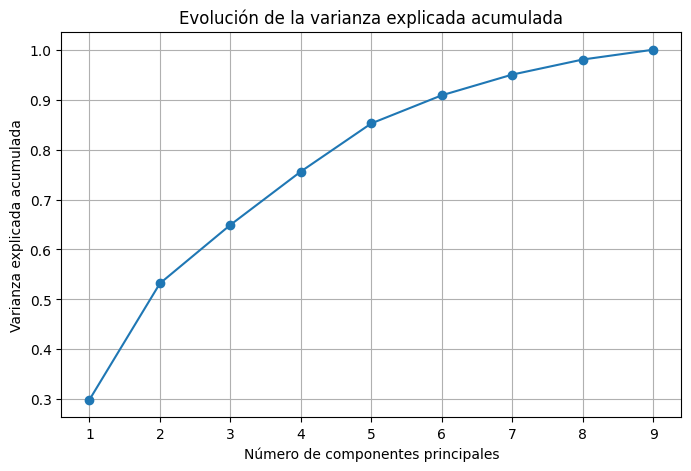

In [99]:
plt.figure(figsize=(8, 5))
plt.plot(
    range(1, len(varianza_acumulada) + 1),
    varianza_acumulada,
    marker="o"
)

plt.xlabel("Número de componentes principales")
plt.ylabel("Varianza explicada acumulada")
plt.title("Evolución de la varianza explicada acumulada")
plt.grid(True)
plt.show()

Como ya habiamos visto, con 5 se explica el 85% de la varianza.

### Veamos la correlación entre las nuevas componentes y las dimensiones originales
Representa en un mapa de calor los PCA vs las variables originales. Esta información la puedes obtener del atributo de PCA *components_*.

In [100]:
# Nombres de componentes
pc_names = [f"PC{i+1}" for i in range(pca.n_components_)]

# DataFrame con los loadings
loadings = pd.DataFrame(
    pca.components_,
    index=pc_names,
    columns=features_pca
)

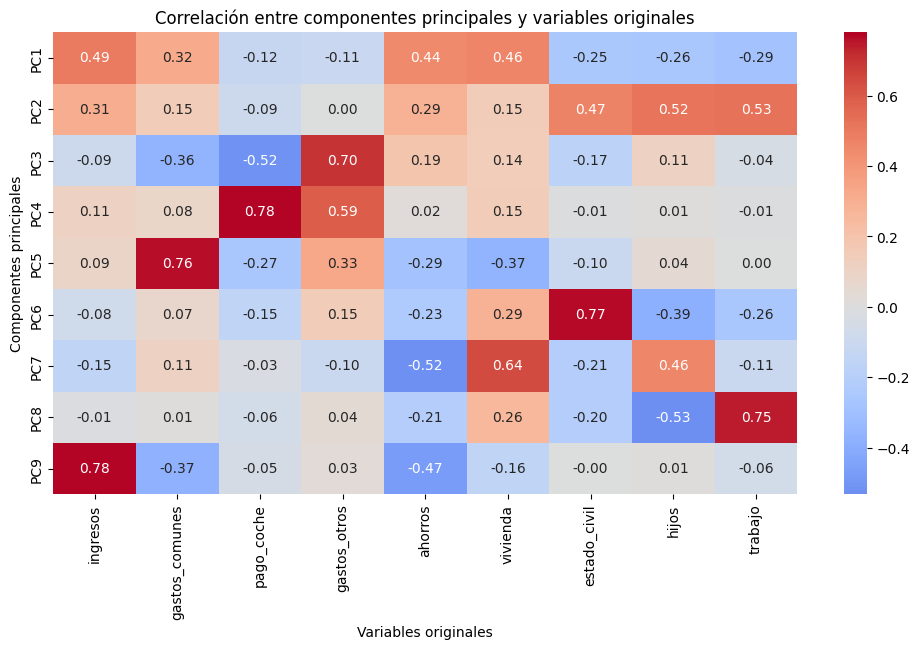

In [101]:
plt.figure(figsize=(12, 6))
sns.heatmap(
    loadings,
    cmap="coolwarm",
    center=0,
    annot=True,
    fmt=".2f"
)

plt.title("Correlación entre componentes principales y variables originales")
plt.xlabel("Variables originales")
plt.ylabel("Componentes principales")
plt.show()


## Predicciones
1. Divide en train y test
2. Prepara un pipeline compuesto por:
    - StandardScaler,
    - PCA de 5 componentes
    - Un clasificador
3. Entrena
4. Predice con test
5. Calcula el accuracy score en train y test
6. Representa la matriz de confusión
7. ¿Qué combinación de parámetros y componentes mejoraría el accuracy en test?
8. Vuelve a iterar de nuevo con un gridsearch
9. Guarda tu mejor modelo

In [102]:
from sklearn.model_selection import train_test_split

X = df.drop(columns="comprar")
y = df["comprar"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [103]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("pca", PCA(n_components=5)),
    ("clf", LogisticRegression(max_iter=1000, random_state=42))
])

In [104]:
pipeline.fit(X_train, y_train)

,steps,"[('scaler', ...), ('pca', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True
,n_components,5
,copy,True
,whiten,False
,svd_solver,'auto'


In [105]:
y_train_pred = pipeline.predict(X_train)
y_test_pred = pipeline.predict(X_test)

In [106]:
from sklearn.metrics import accuracy_score

train_acc = accuracy_score(y_train, y_train_pred)
test_acc = accuracy_score(y_test, y_test_pred)

print(f"Accuracy train: {train_acc:.3f}")
print(f"Accuracy test:  {test_acc:.3f}")

Accuracy train: 0.801
Accuracy test:  0.732


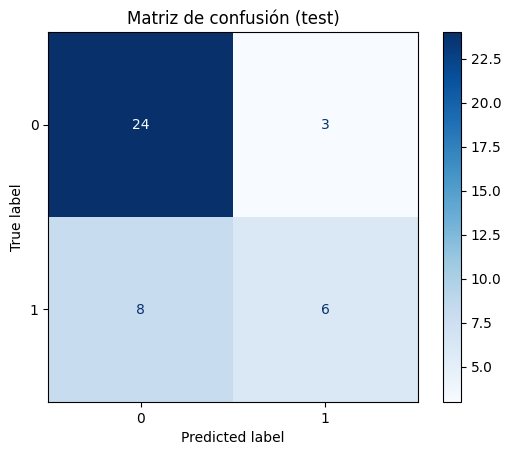

In [107]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_test_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap="Blues")
plt.title("Matriz de confusión (test)")
plt.show()

In [108]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    "pca__n_components": [3, 4, 5, 6, 7],
    "clf__C": [0.01, 0.1, 1, 10],
    "clf__penalty": ["l2"],
    "clf__solver": ["lbfgs"]
}

grid = GridSearchCV(
    pipeline,
    param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

grid.fit(X_train, y_train)

,estimator,Pipeline(step...m_state=42))])
,param_grid,"{'clf__C': [0.01, 0.1, ...], 'clf__penalty': ['l2'], 'clf__solver': ['lbfgs'], 'pca__n_components': [3, 4, ...]}"
,scoring,'accuracy'
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,copy,True


In [109]:
print("Mejores parámetros:", grid.best_params_)
print("Mejor accuracy CV:", grid.best_score_)

Mejores parámetros: {'clf__C': 1, 'clf__penalty': 'l2', 'clf__solver': 'lbfgs', 'pca__n_components': 7}
Mejor accuracy CV: 0.8818181818181818


In [110]:
best_model = grid.best_estimator_

y_test_pred_best = best_model.predict(X_test)
test_acc_best = accuracy_score(y_test, y_test_pred_best)

print(f"Accuracy test (mejor modelo): {test_acc_best:.3f}")

Accuracy test (mejor modelo): 0.805


In [111]:
import joblib

joblib.dump(best_model, "modelo_pca_clasificacion.pkl")

['modelo_pca_clasificacion.pkl']